# Figure 3: Dynamics of decision parameters across action costs.

## setup and imports

In [2]:
import fnmatch
import matplotlib.pyplot as plt
import numpy as np
import glob

from sessionlists import (dist60, dist90, dist120, TM20, TM10, TM2, TMrev2, TMrev10, TMrev20)
from utils import *
from plotting import *
from model_functions import *
from initialize_notebook import initialize_notebook

plt.style.use('./Figures/paper.mplstyle')

In [3]:
root, rat_lists, rat_markers, (example_rat, example_session), GENERAL_PLOT_PARAMS = initialize_notebook()
intact_rats, DSlesioned_rats, VSlesioned_rats, sham_rats, all_rats = rat_lists

Found 84 rats in the DATA folder
Listed 57 rats in total, of which 19 are intact (8♀, 11♂), 19 DS lesions, 15 VS lesions and 4 shams.
Example rat is RatM00, example session: RatM00_2021_07_22_16_13_03


In [4]:
sequence = {}

for index, animal in enumerate(DSlesioned_rats):
    for session in sorted(matchsession(animal, dist60+dist90+dist120 + TM20+TM10+TM2+TMrev2+TMrev10+TMrev20)):
        sequence[animal, session] = get_from_pickle(root, animal, session, name="sequence.p")


In [5]:
alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
ex_alpha_0, ex_alpha_t, ex_alpha_u, ex_gamma_0, ex_gamma_t, ex_gamma_u = pickle.load(open("picklejar/example_session_fit_inter_run_duration.p", "rb"))
ex_mu_0, ex_mu_t, ex_mu_u, ex_sigma_0, ex_sigma_t, ex_sigma_u = pickle.load(open("picklejar/example_session_fit_run_duration.p", "rb"))

PLOT_PARAMS = {
    'alpha_0':  dict(fit=alpha_0, ex_fit=ex_alpha_0, yticks=GENERAL_PLOT_PARAMS['alpha_0']['yticks'], ylabel=GENERAL_PLOT_PARAMS['alpha_0']['ylabel'], start='med', end=2),
    'alpha_t':  dict(fit=alpha_t, ex_fit=ex_alpha_t, yticks=GENERAL_PLOT_PARAMS['alpha_t']['yticks'], ylabel=GENERAL_PLOT_PARAMS['alpha_t']['ylabel'], start='med', end=0.4),
    'alpha_u':  dict(fit=alpha_u, ex_fit=ex_alpha_u, yticks=GENERAL_PLOT_PARAMS['alpha_u']['yticks'], ylabel=GENERAL_PLOT_PARAMS['alpha_u']['ylabel'], start=.15, end=.3),
    'gamma_0':  dict(fit=gamma_0, ex_fit=ex_gamma_0, yticks=GENERAL_PLOT_PARAMS['gamma_0']['yticks'], ylabel=GENERAL_PLOT_PARAMS['gamma_0']['ylabel'], start=1, end=.1),
    'gamma_t':  dict(fit=gamma_t, ex_fit=ex_gamma_t, yticks=GENERAL_PLOT_PARAMS['gamma_t']['yticks'], ylabel=GENERAL_PLOT_PARAMS['gamma_t']['ylabel'], start='med', end=-.15),
    'gamma_u':  dict(fit=gamma_u, ex_fit=ex_gamma_u, yticks=GENERAL_PLOT_PARAMS['gamma_u']['yticks'], ylabel=GENERAL_PLOT_PARAMS['gamma_u']['ylabel'], start='med', end=-.4),
    'mu_0':     dict(fit=mu_0, ex_fit=ex_mu_0, yticks=GENERAL_PLOT_PARAMS['mu_0']['yticks'], ylabel=GENERAL_PLOT_PARAMS['mu_0']['ylabel'], start='med', end='med'),
    'mu_t':     dict(fit=mu_t, ex_fit=ex_mu_t, yticks=GENERAL_PLOT_PARAMS['mu_t']['yticks'], ylabel=GENERAL_PLOT_PARAMS['mu_t']['ylabel'], start='med', end=.12),
    'mu_u':     dict(fit=mu_u, ex_fit=ex_mu_u, yticks=GENERAL_PLOT_PARAMS['mu_u']['yticks'], ylabel=GENERAL_PLOT_PARAMS['mu_u']['ylabel'], start=0.05, end=.15),
    'sigma_0':  dict(fit=sigma_0, ex_fit=ex_sigma_0, yticks=GENERAL_PLOT_PARAMS['sigma_0']['yticks'], ylabel=GENERAL_PLOT_PARAMS['sigma_0']['ylabel'], start='med', end=.15),
    'sigma_t':  dict(fit=sigma_t, ex_fit=ex_sigma_t, yticks=GENERAL_PLOT_PARAMS['sigma_t']['yticks'], ylabel=GENERAL_PLOT_PARAMS['sigma_t']['ylabel'], start='med', end=0.04),
    'sigma_u':  dict(fit=sigma_u, ex_fit=ex_sigma_u, yticks=GENERAL_PLOT_PARAMS['sigma_u']['yticks'], ylabel=GENERAL_PLOT_PARAMS['sigma_u']['ylabel'], start='med', end=0.08),
}


# 3B Effect of distance on α0, αt and αu
# 3C Effect of distance on γ0, γt and γu

In [6]:
dist_shuffled_slopes, dist_p_value_slope, dist_observed_slope = [], [], []
dist_shuffled_intercepts, dist_p_value_intercept, dist_observed_intercept = [], [], []
tm_shuffled_slopes, tm_p_value_slope, tm_observed_slope = [], [], []
tm_shuffled_intercepts, tm_p_value_intercept, tm_observed_intercept = [], [], []

vars = [alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u][::-1]
names = [r'$\alpha_0$', r'$\alpha_t$', r'$\alpha_U$', r'$\gamma_0$', r'$\gamma_t$', r'$\gamma_U$', r'$\mu_0$', r'$\mu_t$', r'$\mu_U$', r'$\sigma_0$', r'$\sigma_t$', r'$\sigma_U$'][::-1]
for var in vars:
    shuffled_slopes, p_value_slope, observed_slope, shuffled_intercepts, p_value_intercept, observed_intercept = compute_regression_permutation(var, dist_or_tm='dist', animal_list=DSlesioned_rats, num_iterations=10000)

    dist_shuffled_slopes.append(shuffled_slopes)
    dist_p_value_slope.append(p_value_slope)
    dist_observed_slope.append(observed_slope)
    dist_shuffled_intercepts.append(shuffled_intercepts)
    dist_p_value_intercept.append(p_value_intercept)
    dist_observed_intercept.append(observed_intercept)

    shuffled_slopes, p_value_slope, observed_slope, shuffled_intercepts, p_value_intercept, observed_intercept = compute_regression_permutation(var, dist_or_tm='tm', animal_list=DSlesioned_rats, num_iterations=10000)
    tm_shuffled_slopes.append(shuffled_slopes)
    tm_p_value_slope.append(p_value_slope)
    tm_observed_slope.append(observed_slope)
    tm_shuffled_intercepts.append(shuffled_intercepts)
    tm_p_value_intercept.append(p_value_intercept)
    tm_observed_intercept.append(observed_intercept)

p_s=0.560, p_i=0.000, obs_slope=0.002, obs_intercept=0.026
p_s=0.942, p_i=0.000, obs_slope=-0.000, obs_intercept=0.025
p_s=0.363, p_i=0.000, obs_slope=0.002, obs_intercept=0.004
p_s=0.016, p_i=0.000, obs_slope=0.002, obs_intercept=0.003
p_s=0.285, p_i=0.000, obs_slope=-0.010, obs_intercept=0.116
p_s=0.001, p_i=0.000, obs_slope=0.010, obs_intercept=0.091
p_s=0.710, p_i=0.451, obs_slope=-0.003, obs_intercept=0.004
p_s=0.132, p_i=0.099, obs_slope=-0.006, obs_intercept=0.021
p_s=0.094, p_i=0.000, obs_slope=0.008, obs_intercept=0.047
p_s=0.025, p_i=0.000, obs_slope=0.005, obs_intercept=0.048
p_s=0.000, p_i=0.000, obs_slope=0.274, obs_intercept=0.968
p_s=0.000, p_i=0.000, obs_slope=0.093, obs_intercept=1.459
p_s=0.570, p_i=0.000, obs_slope=-0.009, obs_intercept=-0.168
p_s=0.071, p_i=0.000, obs_slope=0.010, obs_intercept=-0.215
p_s=0.149, p_i=0.000, obs_slope=0.007, obs_intercept=-0.043
p_s=0.314, p_i=0.000, obs_slope=0.003, obs_intercept=-0.068
p_s=0.985, p_i=0.000, obs_slope=0.001, obs_inte

# 3E Effect of treadmill on α0, αt and αu
# 3F Effect of treadmill on γ0, γt and γu

# Figure 3: Dynamics of decision parameters across action costs.

/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/IPython/core/pylabtools.py:151: UserWarning: constrained_layout not applied.  At least one axes collapsed to zero width or height.
  fig.canvas.print_figure(bytes_io, **kw)


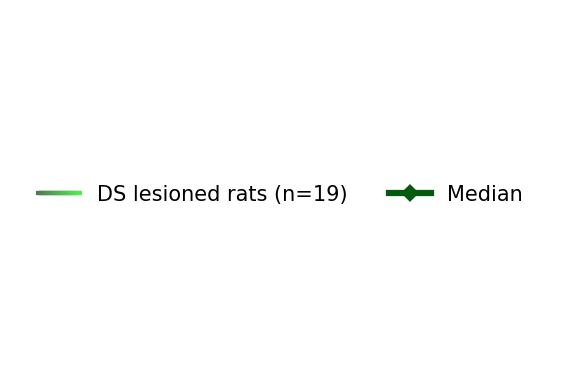

In [10]:
def dummy_legend(ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    
    median_lesion = ax.plot([-100, -101], [-100, -101], color='xkcd:deep green', marker='D', markersize=2, linestyle='-', lw=1.5, label=f'Median lesioned rats', zorder=5)

    add_colored_lesion(ax=ax, loc='center', bbox=(.5, .5), ncol=2,
                       handles=[median_lesion], labels=['Median'],
                       text=f'DS lesioned rats (n={len(DSlesioned_rats)})')
    ax.axis('off')
    ax.set_xlim(10, 11)
    ax.set_ylim(10, 11)

fig, axs = plt.subplots(1, 1, figsize=(cm2inch(3), cm2inch(3)))
dummy_legend(ax=axs)

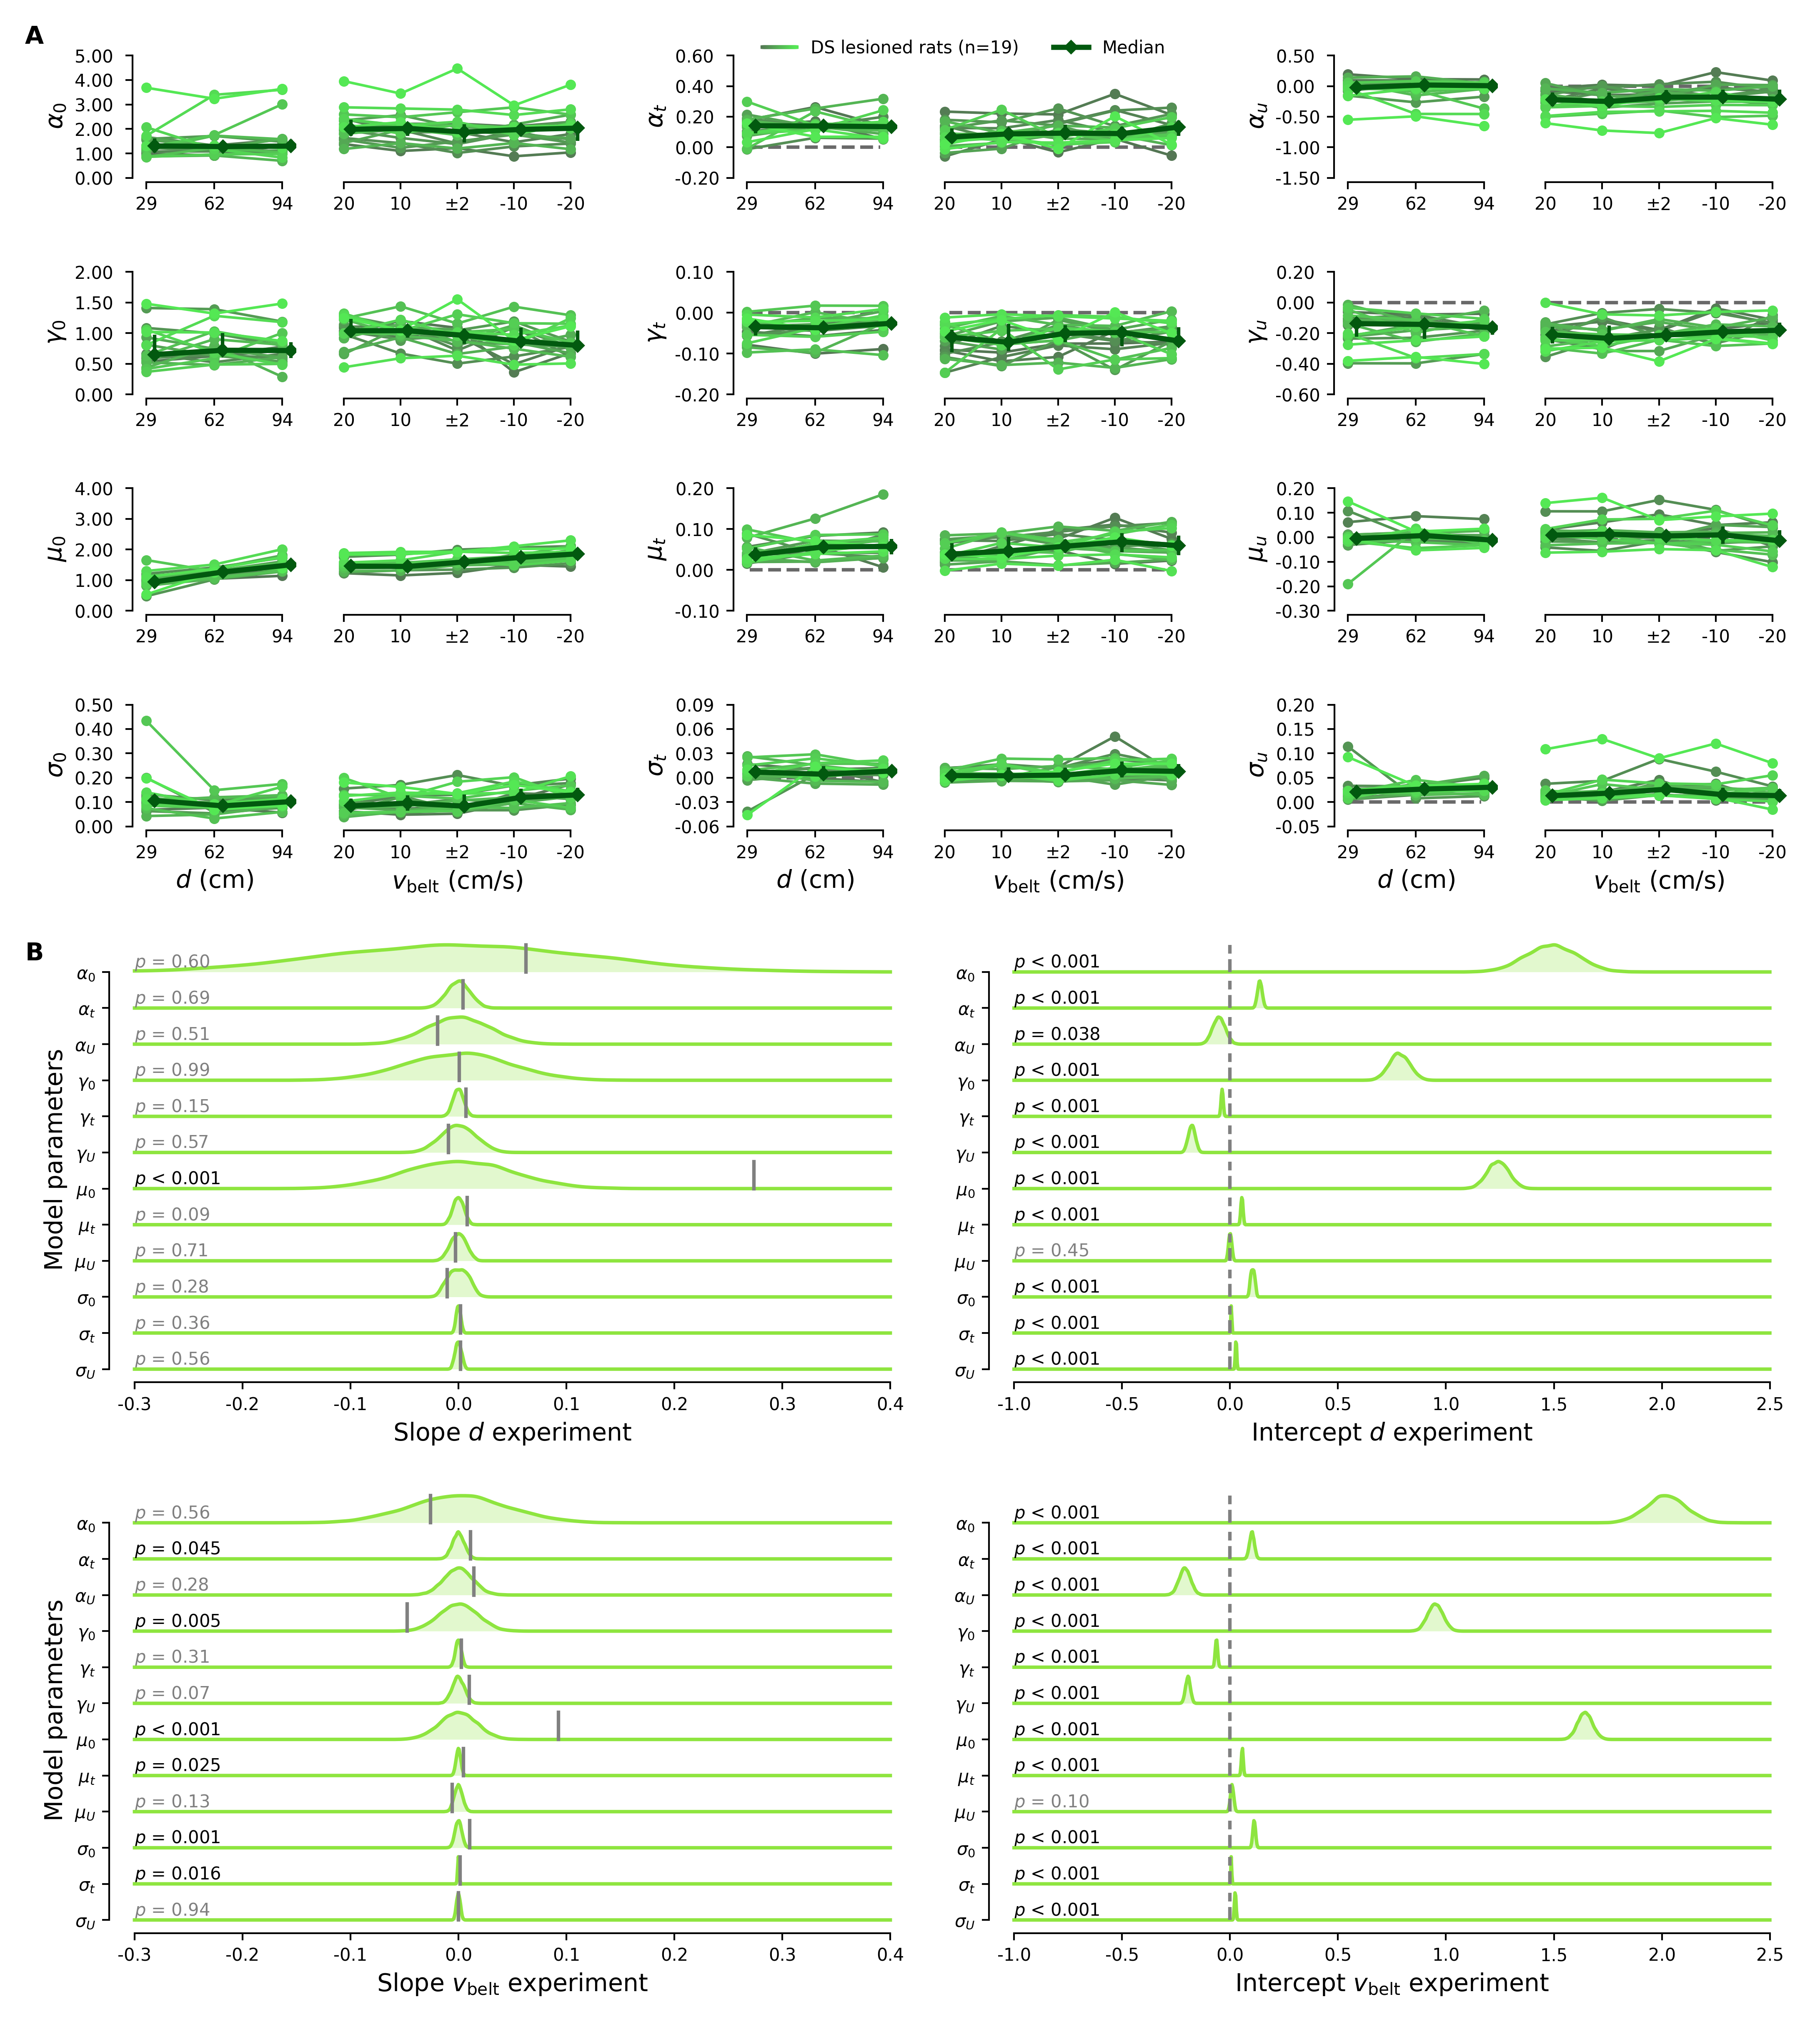

In [11]:

fig = plt.figure(figsize=(cm2inch(18), cm2inch(20)),
                #  constrained_layout=True,
                 facecolor='w', dpi=600)

pad = 0.0001
width_ratios = [3, 5, pad, 3, 5, pad, 3, 5]
gs0 = fig.add_gridspec(6, 1, height_ratios=[1, 1, 1, 1, .1, 5])

row1 = gs0[0].subgridspec(1, 8, width_ratios=width_ratios)
fit_alpha_0_distance = plt.subplot(row1[0])
fit_alpha_0_vbelt = plt.subplot(row1[1])

fit_alpha_t_distance = plt.subplot(row1[3])
fit_alpha_t_vbelt = plt.subplot(row1[4])

fit_alpha_u_distance = plt.subplot(row1[6])
fit_alpha_u_vbelt = plt.subplot(row1[7])

row2 = gs0[1].subgridspec(1, 8, width_ratios=width_ratios)
fit_gamma_0_distance = plt.subplot(row2[0])
fit_gamma_0_vbelt = plt.subplot(row2[1])

fit_gamma_t_distance = plt.subplot(row2[3])
fit_gamma_t_vbelt = plt.subplot(row2[4])

fit_gamma_u_distance = plt.subplot(row2[6])
fit_gamma_u_vbelt = plt.subplot(row2[7])


row3 = gs0[2].subgridspec(1, 8, width_ratios=width_ratios)
fit_mu_0_distance = plt.subplot(row3[0])
fit_mu_0_vbelt = plt.subplot(row3[1])

fit_mu_t_distance = plt.subplot(row3[3])
fit_mu_t_vbelt = plt.subplot(row3[4])

fit_mu_u_distance = plt.subplot(row3[6])
fit_mu_u_vbelt = plt.subplot(row3[7])

row4 = gs0[3].subgridspec(1, 8, width_ratios=width_ratios)
fit_sigma_0_distance = plt.subplot(row4[0])
fit_sigma_0_vbelt = plt.subplot(row4[1])

fit_sigma_t_distance = plt.subplot(row4[3])
fit_sigma_t_vbelt = plt.subplot(row4[4])

fit_sigma_u_distance = plt.subplot(row4[6])
fit_sigma_u_vbelt = plt.subplot(row4[7])

row5 = gs0[5].subgridspec(2, 2)
ax_slope_d = plt.subplot(row5[0, 0])
ax_intercept_d = plt.subplot(row5[0, 1])
ax_slope_tm = plt.subplot(row5[1, 0])
ax_intercept_tm = plt.subplot(row5[1, 1])

plot_model_parameter(PLOT_PARAMS['alpha_0'], rat_markers, dist_or_tm='dist', show_ex=False, ax=fit_alpha_0_distance, show_ylabel=True, animal_list=DSlesioned_rats, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['alpha_t'], rat_markers, dist_or_tm='dist', show_ex=False, ax=fit_alpha_t_distance, show_ylabel=True, animal_list=DSlesioned_rats, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['alpha_u'], rat_markers, dist_or_tm='dist', show_ex=False, ax=fit_alpha_u_distance, show_ylabel=True, animal_list=DSlesioned_rats, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['gamma_0'], rat_markers, dist_or_tm='dist', show_ex=False, ax=fit_gamma_0_distance, show_ylabel=True, animal_list=DSlesioned_rats, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['gamma_t'], rat_markers, dist_or_tm='dist', show_ex=False, ax=fit_gamma_t_distance, show_ylabel=True, animal_list=DSlesioned_rats, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['gamma_u'], rat_markers, dist_or_tm='dist', show_ex=False, ax=fit_gamma_u_distance, show_ylabel=True, animal_list=DSlesioned_rats, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['mu_0'], rat_markers, dist_or_tm='dist', show_ex=False, ax=fit_mu_0_distance, show_ylabel=True, animal_list=DSlesioned_rats, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['mu_t'], rat_markers, dist_or_tm='dist', show_ex=False, ax=fit_mu_t_distance, show_ylabel=True, animal_list=DSlesioned_rats, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['mu_u'], rat_markers, dist_or_tm='dist', show_ex=False, ax=fit_mu_u_distance, show_ylabel=True, animal_list=DSlesioned_rats, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['sigma_0'], rat_markers, dist_or_tm='dist', show_ex=False, ax=fit_sigma_0_distance, show_xlabel=True, show_ylabel=True, animal_list=DSlesioned_rats, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['sigma_t'], rat_markers, dist_or_tm='dist', show_ex=False, ax=fit_sigma_t_distance, show_xlabel=True, show_ylabel=True, animal_list=DSlesioned_rats, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['sigma_u'], rat_markers, dist_or_tm='dist', show_ex=False, ax=fit_sigma_u_distance, show_xlabel=True, show_ylabel=True, animal_list=DSlesioned_rats, median_color='xkcd:deep green')


plot_model_parameter(PLOT_PARAMS['alpha_0'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_alpha_0_vbelt, animal_list=DSlesioned_rats, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['alpha_t'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_alpha_t_vbelt, animal_list=DSlesioned_rats, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['alpha_u'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_alpha_u_vbelt, animal_list=DSlesioned_rats, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['gamma_0'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_gamma_0_vbelt, animal_list=DSlesioned_rats, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['gamma_t'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_gamma_t_vbelt, animal_list=DSlesioned_rats, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['gamma_u'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_gamma_u_vbelt, animal_list=DSlesioned_rats, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['mu_0'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_mu_0_vbelt, animal_list=DSlesioned_rats, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['mu_t'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_mu_t_vbelt, animal_list=DSlesioned_rats, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['mu_u'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_mu_u_vbelt, animal_list=DSlesioned_rats, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['sigma_0'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_sigma_0_vbelt, show_xlabel=True, animal_list=DSlesioned_rats, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['sigma_t'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_sigma_t_vbelt, show_xlabel=True, animal_list=DSlesioned_rats, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter(PLOT_PARAMS['sigma_u'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_sigma_u_vbelt, show_xlabel=True, animal_list=DSlesioned_rats, hide_y=True, median_color='xkcd:deep green')

ridgeline(dist_shuffled_slopes, observed_vals=dist_observed_slope, pvals=dist_p_value_slope, overlap=.0, ax=ax_slope_d, labels=names, x_ticks=[-0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3, 0.4], ylabel='Model parameters', xlabel=r'Slope $d$ experiment', color='xkcd:kiwi green')
ridgeline(dist_shuffled_intercepts, observed_vals=dist_observed_intercept, pvals=dist_p_value_intercept, overlap=.0, ax=ax_intercept_d, labels=names, x_ticks=[-1, -0.5, 0, 0.5, 1, 1.5, 2, 2.5], show_zero=True, xlabel=r'Intercept $d$ experiment', color='xkcd:kiwi green')
ridgeline(tm_shuffled_slopes, observed_vals=tm_observed_slope, pvals=tm_p_value_slope, overlap=.0, ax=ax_slope_tm, labels=names, x_ticks=[-0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3, 0.4], ylabel='Model parameters', xlabel=r'Slope $v_{\mathrm{belt}}$ experiment', color='xkcd:kiwi green')
ridgeline(tm_shuffled_intercepts, observed_vals=tm_observed_intercept, pvals=tm_p_value_intercept, overlap=.0, ax=ax_intercept_tm, labels=names, x_ticks=[-1, -0.5, 0, 0.5, 1, 1.5, 2, 2.5], show_zero=True, xlabel=r'Intercept $v_{\mathrm{belt}}$ experiment', color='xkcd:kiwi green')


legend = fig.add_axes([.52, .99, .01, .01])
dummy_legend(ax=legend)

add_all_letters([fit_alpha_0_distance, ax_slope_d], ["A", "B"])


plt.savefig("./Figures_paper/Figure_S1213.pdf", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)
plt.savefig("./Figures_paper/Figure_S1213.svg", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="svg", dpi=600)